# Eksperimen Model Forecasting Inflasi
Notebook ini membandingkan berbagai model Machine Learning untuk melakukan prediksi Inflasi bulanan (MoM) menggunakan **seluruh fitur** yang tersedia (42+ fitur termasuk komoditas internasional, GPR, FAO, dll).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data & Imputasi
Kita menggunakan data `clean_inflasi_ts.csv` yang sudah dibersihkan dan diimputasi oleh pipeline.

In [2]:
data_path = os.path.join('..', 'datasets', 'processed', 'clean_inflasi_ts.csv')
df = pd.read_csv(data_path)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)
df.set_index('Tanggal', inplace=True)

# Drop kolom yang bukan numerik atau target leak
# Kita simpan semua fitur numerik yang tersedia
exclude_cols = ['Bulan', 'Tahun'] # Kita akan buat fitur siklikal nanti
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Imputasi sisa NaN dengan ffill dan bfill (seharusnya sudah bersih)
df = df.ffill().bfill()

print(f"Shape data: {df.shape}")
print(f"Jumlah fitur: {len(feature_cols)}")
df.head()

Shape data: (257, 44)
Jumlah fitur: 42


,Inflasi_MoM,IHK,BI_Rate,USD_IDR,Inflasi_Umum_MoM,Inflasi_Inti_MoM,Inflasi_HargaDiatur_MoM,Inflasi_Bergejolak_MoM,Harga_Minyak_USD,Brent_USD,...,CMO_Tin_USD,CMO_Nickel_USD,CMO_Copper_USD,CMO_Aluminum_USD,CMO_IronOre_USD,CMO_NatGas_USD,CMO_NatGas_EU_USD,CMO_LNG_Japan_USD,Bulan,Tahun
Tanggal,,,,,,,,,,,,,,,,,,,,,
2005-01-01,1.43,118.53,7.32,9165.0,-0.07,0.44,-2.67,0.79,42.97,76.395,...,8553.81,13768.81,3145.45,1849.18,37.9,6.58,5.01,5.57,1,2005
2005-02-01,-0.17,118.33,7.15,9264.5,-0.07,0.44,-2.67,0.79,44.82,76.395,...,7735.75,14505.00,3170.00,1834.43,65.0,6.15,5.46,5.42,2,2005
2005-03-01,1.91,120.59,8.81,9471.0,-0.07,0.44,-2.67,0.79,50.94,76.395,...,8088.75,15349.50,3253.70,1882.85,65.0,6.14,5.49,5.58,3,2005
2005-04-01,0.34,121.00,8.12,9570.0,-0.07,0.44,-2.67,0.79,50.64,76.395,...,8407.39,16190.65,3379.49,1979.85,65.0,6.97,5.52,5.59,4,2005
2005-05-01,0.21,121.25,7.40,9518.0,-0.07,0.44,-2.67,0.79,47.83,76.395,...,8143.81,16141.91,3394.48,1894.29,65.0,7.15,5.86,5.67,5,2005


## 2. Feature Engineering Lanjutan
Menambahkan fitur siklikal untuk bulan dan beberapa fitur interaksi/lag.

In [3]:
# Fitur Siklikal Bulan
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan']/12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan']/12)

# Update feature list
feature_cols.extend(['Bulan_Sin', 'Bulan_Cos'])

# Fitur Interaksi Sederhana (Contoh)
if 'Harga_Minyak_USD' in df.columns and 'USD_IDR' in df.columns:
    df['Oil_x_USDIDR'] = df['Harga_Minyak_USD'] * df['USD_IDR']
    feature_cols.append('Oil_x_USDIDR')

print(f"Total fitur setelah engineering: {len(feature_cols)}")

Total fitur setelah engineering: 45


## 3. Pembuatan Fitur Lag & Windowing
Untuk memprediksi inflasi, kita membuat sekuens historis (12 bulan ke belakang).

In [4]:
lag_steps = 12

df_ml = df.copy()
tabular_features = []

# Buat Lag Features untuk SEMUA fitur (kecuali target nanti)
for feat in feature_cols:
    if feat == 'Inflasi_MoM': continue # Target
    for i in range(1, lag_steps + 1):
        col_name = f"{feat}_lag{i}"
        df_ml[col_name] = df_ml[feat].shift(i)
        tabular_features.append(col_name)

# Juga buat lag target (autoregressive)
for i in range(1, lag_steps + 1):
    col_name = f"Inflasi_MoM_lag{i}"
    df_ml[col_name] = df_ml['Inflasi_MoM'].shift(i)
    tabular_features.append(col_name)

# Drop baris NaN akibat shifting
df_ml.dropna(inplace=True)

X_tabular = df_ml[tabular_features].values
y_tabular = df_ml['Inflasi_MoM'].values
dates_tabular = df_ml.index

print(f"Shape Fitur Tabular: {X_tabular.shape}")

Shape Fitur Tabular: (245, 540)


## 4. Chronological Train-Test Split

In [5]:
n = len(X_tabular)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X_tabular[:train_end], y_tabular[:train_end]
X_val, y_val = X_tabular[train_end:val_end], y_tabular[train_end:val_end]
X_test, y_test = X_tabular[val_end:], y_tabular[val_end:]

dates_test = dates_tabular[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (171, 540), Val: (37, 540), Test: (37, 540)


## 5. Model 1: Regularized Regression (Ridge)

In [6]:
# Ridge Regression lebih cocok untuk banyak fitur
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge Regression -> MAE: {mae_ridge:.4f}, RMSE: {rmse_ridge:.4f}")

Ridge Regression -> MAE: 5.9988, RMSE: 6.7765


## 6. Model 2: Random Forest Regressor

In [7]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")

Random Forest -> MAE: 0.5022, RMSE: 0.6211


## 7. Model 3: Gradient Boosting (XGBoost/LightGBM style)

In [8]:
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting -> MAE: {mae_gb:.4f}, RMSE: {rmse_gb:.4f}")

Gradient Boosting -> MAE: 0.4672, RMSE: 0.5861


## 8. Model 4: LSTM (Long Short-Term Memory)
Menggunakan arsitektur yang lebih dalam dengan Dropout dan Early Stopping.

In [9]:
# Siapkan Data untuk LSTM
lstm_features = ['Inflasi_MoM'] + [c for c in df.columns if c not in ['Inflasi_MoM', 'Bulan', 'Tahun']]
df_lstm = df[lstm_features].copy()

# Scaling (Target terpisah agar inverse mudah)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scaler HANYA pada data train (hindari leakage)
# Train limit termasuk lag awal agar sequence valid
train_limit_idx = df_lstm.index[train_end]

X_all = df_lstm.drop('Inflasi_MoM', axis=1).values
y_all = df_lstm['Inflasi_MoM'].values.reshape(-1, 1)

# Scaler fit pada 70% data pertama
scaler_X.fit(X_all[:train_end])
scaler_y.fit(y_all[:train_end])

X_scaled = scaler_X.transform(X_all)
y_scaled = scaler_y.transform(y_all)

def create_lstm_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_lstm_sequences(X_scaled, y_scaled, lag_steps)

# Split sesuai indeks waktu
X_train_lstm = torch.tensor(X_seq[:train_end], dtype=torch.float32).to(device)
y_train_lstm = torch.tensor(y_seq[:train_end], dtype=torch.float32).to(device)

X_val_lstm = torch.tensor(X_seq[train_end:val_end], dtype=torch.float32).to(device)
y_val_lstm = torch.tensor(y_seq[train_end:val_end], dtype=torch.float32).to(device)

X_test_lstm = torch.tensor(X_seq[val_end:], dtype=torch.float32).to(device)
y_test_lstm = torch.tensor(y_seq[val_end:], dtype=torch.float32).to(device)

input_size = X_train_lstm.shape[2]
print(f"LSTM Input Size: {input_size} fitur")

LSTM Input Size: 44 fitur


In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1, :])
        out = self.fc(out)
        return out

hidden_size = 128
num_layers = 2
lstm_model = LSTMModel(input_size, hidden_size, num_layers, 1).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training Loop dengan Early Stopping
epochs = 200
patience = 30
best_val_loss = float('inf')
counter = 0
best_model_state = None

for epoch in range(epochs):
    lstm_model.train()
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm)
    loss = criterion(outputs, y_train_lstm)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    
    # Validation
    lstm_model.eval()
    with torch.no_grad():
        val_outputs = lstm_model(X_val_lstm)
        val_loss = criterion(val_outputs, y_val_lstm)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = lstm_model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
            
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")

# Load best model
lstm_model.load_state_dict(best_model_state)

Epoch 50: Train Loss: 0.003475, Val Loss: 0.003481
Early stopping at epoch 88


<All keys matched successfully>

In [11]:
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_test_lstm).cpu().numpy()

# Inverse transform
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_lstm.cpu().numpy())

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print(f"LSTM Advanced -> MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

LSTM Advanced -> MAE: 0.3384, RMSE: 0.4600


## 8B. Model 5: ARIMA (AutoRegressive Integrated Moving Average)

Model statistik klasik untuk time series forecasting.
- **AR(p)**: AutoRegressive - menggunakan nilai masa lalu
- **I(d)**: Integrated - differencing untuk stasioneritas
- **MA(q)**: Moving Average - menggunakan error masa lalu

Grid search untuk parameter optimal (p,d,q) berdasarkan AIC terendah.

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from itertools import product
import pickle
print('statsmodels loaded')

statsmodels loaded


In [13]:
ts_arima = df_ml['Inflasi_MoM'].dropna()

print('=' * 50)
print('UJI STACIONERITAS (Augmented Dickey-Fuller)')
print('=' * 50)

d_order = 0
for d_test in range(3):
    data = ts_arima if d_test == 0 else ts_arima.diff(d_test).dropna()
    result = adfuller(data)
    p_val = result[1]
    status = 'STATIONER' if p_val <= 0.05 else 'Belum stationer'
    label = 'Original' if d_test == 0 else f'Differenced (d={d_test})'
    print(f'{label}: ADF={result[0]:.4f}, p={p_val:.6f} -> {status}')
    if p_val <= 0.05:
        d_order = d_test
        print(f'Rekomendasi d = {d_order}')
        break
else:
    d_order = 2
    print(f'Gunakan d = {d_order}')

UJI STACIONERITAS (Augmented Dickey-Fuller)
Original: ADF=-3.2196, p=0.018880 -> STATIONER
Rekomendasi d = 0


In [14]:
p_range = range(0, 5)
q_range = range(0, 5)

split_arima = int(len(ts_arima) * 0.8)
train_arima = ts_arima.iloc[:split_arima]
test_arima = ts_arima.iloc[split_arima:]

print(f'Train: {len(train_arima)} obs | Test: {len(test_arima)} obs')
print(f'Grid Search ARIMA(p,{d_order},q)...')

results_arima = []
best_aic = float('inf')
best_order_arima = (1, d_order, 1)

for p, q in product(p_range, q_range):
    try:
        model = ARIMA(train_arima, order=(p, d_order, q))
        fitted = model.fit()
        pred = fitted.forecast(steps=len(test_arima))
        mae_val = mean_absolute_error(test_arima, pred)
        rmse_val = np.sqrt(mean_squared_error(test_arima, pred))
        results_arima.append({'order': (p, d_order, q), 'aic': fitted.aic, 'mae': mae_val, 'rmse': rmse_val})
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order_arima = (p, d_order, q)
    except Exception:
        continue

results_arima.sort(key=lambda x: x['aic'])
print(f'\nTop 5 ARIMA Models:')
for r in results_arima[:5]:
    print(f"  ARIMA{r['order']}: AIC={r['aic']:.2f} MAE={r['mae']:.4f} RMSE={r['rmse']:.4f}")
print(f'\nBest: ARIMA{best_order_arima} (AIC={best_aic:.2f})')

Train: 196 obs | Test: 49 obs
Grid Search ARIMA(p,0,q)...


C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\Local


Top 5 ARIMA Models:
  ARIMA(3, 0, 3): AIC=209.11 MAE=0.3381 RMSE=0.4420
  ARIMA(2, 0, 3): AIC=209.18 MAE=0.3369 RMSE=0.4440
  ARIMA(3, 0, 4): AIC=209.47 MAE=0.3388 RMSE=0.4460
  ARIMA(2, 0, 4): AIC=209.59 MAE=0.3381 RMSE=0.4412
  ARIMA(3, 0, 2): AIC=210.33 MAE=0.3386 RMSE=0.4419

Best: ARIMA(3, 0, 3) (AIC=209.11)


C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
final_arima = ARIMA(ts_arima, order=best_order_arima)
final_arima_fitted = final_arima.fit()

pred_ins = final_arima_fitted.fittedvalues
mae_arima = mean_absolute_error(ts_arima.iloc[1:], pred_ins.iloc[1:])
rmse_arima = np.sqrt(mean_squared_error(ts_arima.iloc[1:], pred_ins.iloc[1:]))

print(final_arima_fitted.summary())
print(f'\nIn-sample MAE: {mae_arima:.4f}')
print(f'In-sample RMSE: {rmse_arima:.4f}')

C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Inflasi_MoM   No. Observations:                  245
Model:                 ARIMA(3, 0, 3)   Log Likelihood                -129.658
Date:                Fri, 05 Jun 2026   AIC                            275.315
Time:                        23:59:48   BIC                            303.325
Sample:                    01-01-2006   HQIC                           286.595
                         - 05-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3746      0.049      7.636      0.000       0.278       0.471
ar.L1          1.1559      0.129      8.971      0.000       0.903       1.408
ar.L2         -1.1231      0.119     -9.432      0.0

C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Forecast ARIMA 3 Bulan:
  Jun 2026: 0.2501% (95% CI: [-0.5520%, 1.0522%])
  Jul 2026: 0.2843% (95% CI: [-0.5989%, 1.1675%])
  Aug 2026: 0.4240% (95% CI: [-0.4597%, 1.3076%])


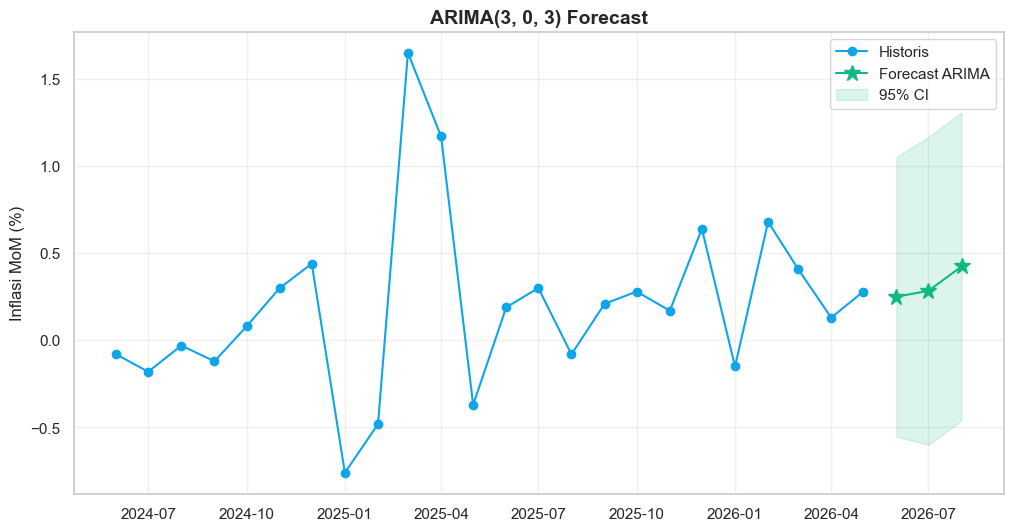

Model saved: models/arima_inflasi.pkl
Forecast saved: models/arima_forecast.pkl


In [16]:
forecast_arima = final_arima_fitted.get_forecast(steps=3)
fc_mean = forecast_arima.predicted_mean
fc_ci = forecast_arima.conf_int(alpha=0.05)
fc_dates = pd.date_range(start=ts_arima.index[-1], periods=4, freq='MS')[1:]

print('Forecast ARIMA 3 Bulan:')
for i in range(3):
    d = fc_dates[i].strftime('%b %Y')
    m = fc_mean.iloc[i]
    lo = fc_ci.iloc[i, 0]
    hi = fc_ci.iloc[i, 1]
    print(f'  {d}: {m:.4f}% (95% CI: [{lo:.4f}%, {hi:.4f}%])')

plt.figure(figsize=(12, 6))
recent = ts_arima.last('24M')
plt.plot(recent.index, recent.values, label='Historis', marker='o', color='#0EA5E9')
plt.plot(fc_dates, fc_mean.values, label='Forecast ARIMA', marker='*', color='#10B981', markersize=12)
plt.fill_between(fc_dates, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, color='#10B981', label='95% CI')
plt.title(f'ARIMA{best_order_arima} Forecast', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylabel('Inflasi MoM (%)')
plt.show()

os.makedirs('../models', exist_ok=True)
with open('../models/arima_inflasi.pkl', 'wb') as f:
    pickle.dump(final_arima_fitted, f)
with open('../models/arima_forecast.pkl', 'wb') as f:
    pickle.dump({
        'forecast': {'forecast_mean': fc_mean.tolist(), 'forecast_lower': fc_ci.iloc[:, 0].tolist(), 'forecast_upper': fc_ci.iloc[:, 1].tolist()},
        'order': best_order_arima,
        'last_date': ts_arima.index[-1].strftime('%Y-%m-%d'),
        'last_value': float(ts_arima.iloc[-1])
    }, f)
print(f'Model saved: models/arima_inflasi.pkl')
print(f'Forecast saved: models/arima_forecast.pkl')

## 9. Komparasi Visual & Forecasting Masa Depan
Membandingkan semua model: Ridge, Random Forest, Gradient Boosting, LSTM, dan ARIMA.

               Model       MAE      RMSE
0               LSTM  0.338360  0.459960
1  Gradient Boosting  0.467231  0.586087
2      Random Forest  0.502159  0.621100
3              Ridge  5.998779  6.776470


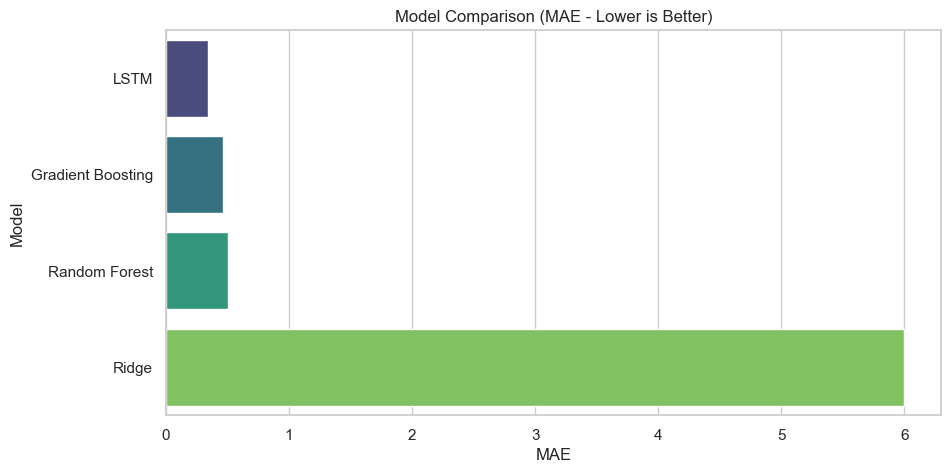

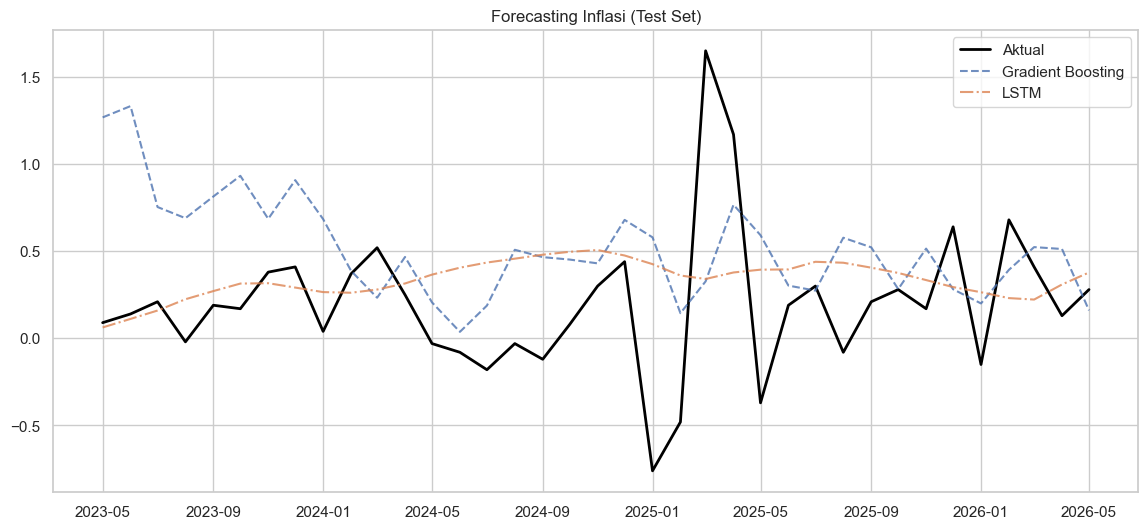

In [17]:
models = ['Ridge', 'Random Forest', 'Gradient Boosting', 'LSTM']
mae_scores = [mae_ridge, mae_rf, mae_gb, mae_lstm]
rmse_scores = [rmse_ridge, rmse_rf, rmse_gb, rmse_lstm]

eval_df = pd.DataFrame({'Model': models, 'MAE': mae_scores, 'RMSE': rmse_scores})
eval_df = eval_df.sort_values('MAE').reset_index(drop=True)
print(eval_df)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='MAE', y='Model', data=eval_df, palette='viridis')
plt.title('Model Comparison (MAE - Lower is Better)')
plt.show()

# Plot Prediksi vs Aktual (Best Model: Gradient Boosting atau LSTM)
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label='Aktual', color='black', linewidth=2)
plt.plot(dates_test, y_pred_gb, label='Gradient Boosting', linestyle='--', alpha=0.8)
plt.plot(dates_test, y_pred_lstm, label='LSTM', linestyle='-.', alpha=0.8)
plt.title('Forecasting Inflasi (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

## 10. Forecasting Mei & Juni 2026

Prediksi May 2026: 0.41%
Prediksi June 2026: 0.42%


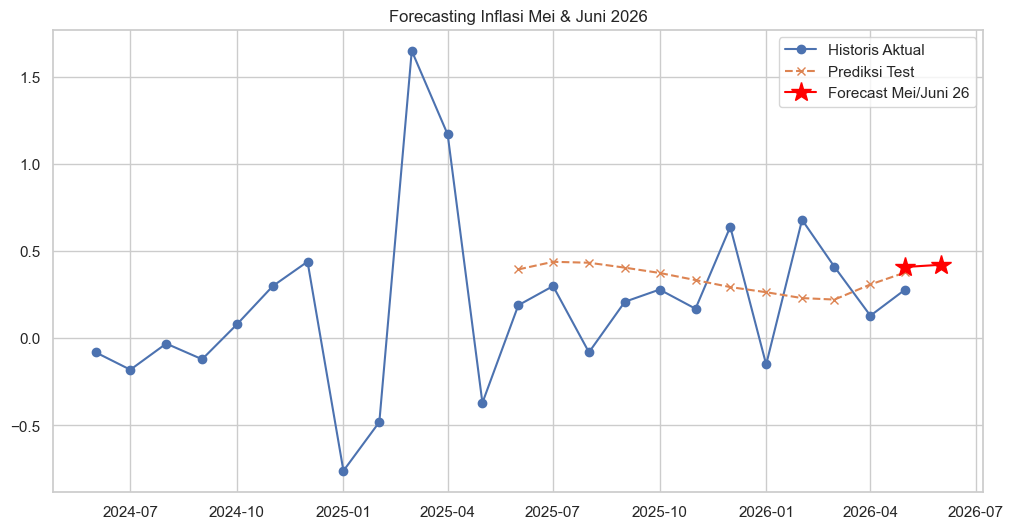

In [18]:
# Kita akan menggunakan LSTM untuk prediksi rekursif
# Asumsi: Data terakhir di dataset adalah April 2026

last_sequence = X_scaled[-lag_steps:] # 12 bulan terakhir
current_seq = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

future_preds = []
future_dates = [pd.Timestamp('2026-05-01'), pd.Timestamp('2026-06-01')]

# Untuk prediksi masa depan, kita asumsikan fitur exogenous (minyak, dll) 
# tetap sama seperti bulan terakhir (atau kita bisa coba asumsi tren sederhana)
# Di sini kita asumsikan flat (konstan) untuk fitur exogenous demi simplisitas

lstm_model.eval()
with torch.no_grad():
    for i in range(2): # Mei dan Juni
        pred_scaled = lstm_model(current_seq) # Shape: (1, 1)
        
        # Simpan prediksi
        pred_real = scaler_y.inverse_transform(pred_scaled.cpu().numpy())[0][0]
        future_preds.append(pred_real)
        print(f"Prediksi {future_dates[i].strftime('%B %Y')}: {pred_real:.2f}%")
        
        # Update sequence untuk prediksi berikutnya
        # Ambil baris terakhir dari sequence saat ini
        last_row = current_seq[0, -1, :].cpu().numpy().copy()
        
        # Update kolom target (Inflasi_MoM) dengan prediksi baru (scaled)
        # Asumsi: Inflasi_MoM ada di index 0 di fitur LSTM
        # Kita perlu cek index Inflasi_MoM di lstm_features
        target_idx = lstm_features.index('Inflasi_MoM')
        last_row[target_idx] = pred_scaled.item()
        
        # Geser sequence: buang bulan pertama, tambah prediksi baru di akhir
        new_seq = torch.cat([current_seq[0, 1:], torch.tensor(last_row).unsqueeze(0).to(device)], dim=0)
        current_seq = new_seq.unsqueeze(0)

# Simpan hasil forecast untuk web
forecast_data = {
    'labels': [d.strftime('%b %Y') for d in dates_test[-12:]] + [d.strftime('%b %Y') for d in future_dates],
    'actual': list(y_test[-12:]) + [None, None],
    'pred': list(y_pred_lstm[-12:]) + future_preds
}

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_test[-24:], y_test[-24:], label='Historis Aktual', marker='o')
plt.plot(dates_test[-12:], y_pred_lstm[-12:], label='Prediksi Test', linestyle='--', marker='x')
plt.plot(future_dates, future_preds, label='Forecast Mei/Juni 26', linestyle='-', marker='*', color='red', markersize=15)
plt.title('Forecasting Inflasi Mei & Juni 2026')
plt.legend()
plt.grid(True)
plt.show()